In [1]:
import os
import time
import pickle
import multiprocessing

os.environ['OPENMDAO_REQUIRE_MPI'] = 'false'  # Suppress OpenMDAO MPI import warnings

from open_turb_arch.architecting import *
from open_turb_arch.architecting.metrics import *
from open_turb_arch.architecting.turbofan import *
from open_turb_arch.evaluation.analysis import *

from open_turb_arch.architecting.pymoo import *
from pymoo.optimize import minimize
from pymoo.algorithms.nsga2 import NSGA2
from pymoo.operators.sampling.latin_hypercube_sampling import LatinHypercubeSampling

import numpy as np

from SALib.sample import morris as morris_sample
from SALib.analyze import morris as morris_analyze

import json

In [2]:
def get_architecting_problem():
    analysis_problem = AnalysisProblem(
        design_condition=DesignCondition(
            # mach=0.78,  # Mach number [-]
            # alt=10668 * 3.28084,  # Altitude [ft]
            # thrust=24900,  # Thrust [N]
            # d_temp=10.0,  # Temperature difference to standard atmosphere [K]
            # turbine_in_temp=1800 - 273.15,  # Turbine inlet temperature [C]
            # bleed_offtake=0,  # Extraction bleed offtake [kg/s]
            # power_offtake=0,  # Power offtake [W]
            # balancer=DesignBalancer(),
            
            # mach=0.8,  # Mach number [-]
            # alt=35000,  # Altitude [ft]
            # thrust=22500,  # Thrust [N]
            # d_temp=0.,  # Temperature difference to standard atmosphere [K]
            # turbine_in_temp=1600 - 273.15,  # Turbine inlet temperature [C]
            # bleed_offtake=0.98,  # Extraction bleed offtake [kg/s]
            # power_offtake=52000,  # Power offtake [W]
            # balancer=DesignBalancer(),
            
            mach=0.78,  # Mach number [-]
            alt=10668 * 3.28084,  # Altitude [ft]
            thrust=24900,  # Thrust [N]
            d_temp=0.,  # Temperature difference to standard atmosphere [K]
            turbine_in_temp=1800 - 273.15,  # Turbine inlet temperature [C]
            bleed_offtake=0.,  # Extraction bleed offtake [kg/s]
            power_offtake=50000,  # Power offtake [W]
            balancer=DesignBalancer(
                init_turbine_pr=10,
                init_mass_flow=400,
                init_extraction_bleed_frac=0.02),
        ),
        evaluate_conditions=[
        #     EvaluateCondition(
        #         name_='Cruise',
        #         mach=0.78,  # Mach number [-]
        #         alt=10668 * 3.28084,  # Altitude [ft]
        #         thrust=20400,  # Thrust [N]
        #         balancer=OffDesignBalancer(
        #             init_bpr=3.8,
        #             init_shaft_rpm=7500.,
        #             init_mass_flow=100.,
        #             init_far=.025,
        #             init_extraction_bleed_frac=0.01
        #         ),
        #         d_temp=0.,  # Temperature difference to standard atmosphere [K]
        #         bleed_offtake=0.,  # Extraction bleed offtake [kg/s]
        #         power_offtake=50000,  # Power offtake [W]
        #     ),
        #     EvaluateCondition(
        #         name_='MCL1',
        #         mach=0.71,  # Mach number [-]
        #         alt=9449 * 3.28084,  # Altitude [ft]
        #         thrust=27200,  # Thrust [N]
        #         balancer=OffDesignBalancer(
        #             init_bpr=3.8,
        #             init_shaft_rpm=7500.,
        #             init_mass_flow=100.,
        #             init_far=.025,
        #             init_extraction_bleed_frac=0.01
        #         ),
        #         d_temp=0.,  # Temperature difference to standard atmosphere [K]
        #         bleed_offtake=0.,  # Extraction bleed offtake [kg/s]
        #         power_offtake=50000,  # Power offtake [W]
        #     ),
        #     # EvaluateCondition(
        #     #     name_='MCL0',
        #     #     mach=0.45,  # Mach number [-]
        #     #     alt=3048 * 3.28084,  # Altitude [ft]
        #     #     thrust=58000,  # Thrust [N]
        #     #     balancer=OffDesignBalancer(
        #     #         init_bpr=3.8,
        #     #         init_shaft_rpm=7500.,
        #     #         init_mass_flow=100.,
        #     #         init_far=.025,
        #     #         init_extraction_bleed_frac=0.01
        #     #     ),
        #     #     d_temp=0.,  # Temperature difference to standard atmosphere [K]
        #     #     bleed_offtake=0.,  # Extraction bleed offtake [kg/s]
        #     #     power_offtake=50000,  # Power offtake [W]
        #     # ),
        #     # EvaluateCondition(
        #     #     name_='TakeOff',
        #     #     mach=0.25,  # Mach number [-]
        #     #     alt=1e-6,  # Altitude [ft]
        #     #     thrust=105000,  # Thrust [N]
        #     #     balancer=OffDesignBalancer(
        #     #         init_bpr=8.5,
        #     #         init_shaft_rpm=8000.,
        #     #         init_mass_flow=200.,
        #     #         init_far=.025,
        #     #         init_extraction_bleed_frac=0.01
        #     #     ),
        #     #     d_temp=0.,  # Temperature difference to standard atmosphere [K]
        #     #     bleed_offtake=0.,  # Extraction bleed offtake [kg/s]
        #     #     power_offtake=50000,  # Power offtake [W]
        #     # ),
        ]
    )

    return ArchitectingProblem(
        analysis_problem=analysis_problem,
        choices=[
            FanChoice(fix_include_fan=True), 
            CRTFChoice(fix_include_crtf=False),
            ShaftChoice(
                fixed_number_shafts=2,     
                ),
            GearboxChoice(fix_include_gear=False),
            AfterburnerChoice(fix_include_afterburner=False),
            ITBChoice(fix_include_itb=False),     
            CoolingBleedChoice(
                # Detail: 
                # recirculating: inter-bleed HPC-burner to LPC:                         0%
                # handling bleed: inter-bleed HPC-LPC (extraction bleed)                0%
                # overboard bleed: intra-bleed HPC (extraction bleed)                   0.5%
                # LPT cooling: intra-bleed HPC to LPT                                   2%
                # HP leakage (a): inter-bleed HPC-burner (extraction bleed)             0%
                # NGV cooling (b): inter-bleed HPC-burner to HPT (stator part)          5%
                # HPT cooling (c): inter-bleed HPC-burner to HPT (rotor part)           5%
                # HP leak to LPT exit: inter-bleed HPC-burner to LPT                    0%
                # Translation: LPC to IPC
                
                # # Inter-bleed HPC-burner
                # fix_eb_hb_total = 0.10,  # Fix the total cooling bleed portion of the inter-bleed between the HPC and burner
                # fix_eb_hbi_frac_w = 0,  # Fix the cooling bleed portion of the IPT as target of the inter-bleed between the HPC and burner
                # fix_eb_hbl_frac_w = 0,  # Fix the cooling bleed portion of the LPT as target of the inter-bleed between the HPC and burner

                # # Inter-bleed IPC-HPC
                # fix_eb_ih_total = 0,  # Fix the total cooling bleed portion of the inter-bleed between the IPC and HPC
                # fix_eb_ihi_frac_w = 0,  # Fix the cooling bleed portion of the IPT as target of the inter-bleed between the IPC and HPC
                # fix_eb_ihl_frac_w = 0,  # Fix the cooling bleed portion of the LPT as target of the inter-bleed between the IPC and HPC

                # # Inter-bleed LPC-IPC
                # fix_eb_li_total = 0,  # Fix the total cooling bleed portion of the inter-bleed between the LPC and IPC
                # fix_eb_lii_frac_w = 0,  # Fix the cooling bleed portion of the IPT as target of the inter-bleed between the LPC and IPC
                # fix_eb_lil_frac_w = 0,  # Fix the cooling bleed portion of the LPT as target of the inter-bleed between the LPC and IPC

                # # Intra-bleed HPC
                # fix_ab_hpc_total = 0.02,  # Fix the total cooling bleed portion of the HPC intra-bleed
                # fix_ab_hi_frac_w = 1,  # Fix the cooling bleed portion of the IPT as target of the HPC intra-bleed
                # fix_ab_hl_frac_w = 0,  # Fix the cooling bleed portion of the LPT as target of the HPC intra-bleed

                # # Intra-bleed IPC
                # fix_ab_ipc_total = 0,  # Fix the total cooling bleed portion of the IPC intra-bleed
                # fix_ab_ii_frac_w = 0,  # Fix the cooling bleed portion of the IPT as target of the IPC intra-bleed
                # fix_ab_il_frac_w = 0,  # Fix the cooling bleed portion of the LPT as target of the IPC intra-bleed

                # # Intra-bleed LPC
                # fix_ab_lpc_total = 0,  # Fix the total cooling bleed portion of the LPC intra-bleed
                # fix_ab_li_frac_w = 0,  # Fix the cooling bleed portion of the IPT as target of the LPC intra-bleed
                # fix_ab_ll_frac_w = 0,  # Fix the cooling bleed portion of the LPT as target of the LPC intra-bleed
            ),
            NozzleMixingChoice(fix_include_mixing=False),       # no nozzle mixing
            IntercoolerChoice(fix_include_ic=False),        # no intercooler   
            OfftakesChoice(
                fix_power_offtake_location=1, # 1: HPC, 2: IPC, 3: LPC
                fix_bleed_offtake_location=1, # 1: HPC, 2: IPC, 3: LPC
            ), 
        ],
        objectives=[
            TSFCMetric(),
            WeightMetric(),
            LengthMetric(),
            DiameterMetric(),
            NOxMetric(),
            NoiseMetric(),
            JetMachMetric(),
        ],
        constraints=[],
        metrics=[
            TSFCMetric(),
            WeightMetric(),
            LengthMetric(),
            DiameterMetric(),
            NOxMetric(),
            NoiseMetric(),
            JetMachMetric(),
        ],
    )

architecting_problem = get_architecting_problem()

In [3]:
# Check current folder
print("Current folder:", os.getcwd())

# Change to current workspace folderif os.path.basename(os.getcwd()) != 'OpenTurbofanArchitecting':
os.chdir('../../../../')  # Change to workspace folder
print("Changed folder to:", os.getcwd())

Current folder: c:\Users\hafiz\University\ISAE-SUPAERO\4. Research Project\Work\OpenTurbofanArchitecting\open_turb_arch\tests\examples
Changed folder to: c:\Users\hafiz\University\ISAE-SUPAERO\4. Research Project\Work


In [22]:
# Define the save folder and filenames for results
save_folder = 'results_latest_morris_14'
save_filename = 'morris_results.txt'
save_filename_combined = 'morris_results_combined.json'

In [23]:
READ_COMBINED = False

if READ_COMBINED:
    # Read json file with results
    morris_results_combined_path = os.path.join(save_folder, save_filename_combined)
    if os.path.exists(morris_results_combined_path):
        with open(morris_results_combined_path, 'r') as f:
            morris_results_combined = json.load(f)

    X_samples = np.array(morris_results_combined["X_samples"])
    Y_samples = np.array(morris_results_combined["Y_samples"])
else:
    # Read txt file with results
    morris_results_path = os.path.join(save_folder, save_filename)
    if os.path.exists(morris_results_path):
        with open(morris_results_path, 'r') as f:
            morris_results = f.read()
    
    # Convert string representations of lists back to numpy arrays
    lines = morris_results.strip().split('\n')
    
    X_samples, Y_samples = np.array([]), np.array([])
    
    for line in lines:
        # Read line as literal list
        data = eval(line)

        x_sample = np.array(data['x'])
        y_sample = np.array(data['y'])
        index_sample = np.array(data['sample_index'])
        
        print("Checking sample index:", index_sample)
        
        if "NaN" in line:
            # print(f"Warning: NaN value found in sample {len(X_samples)+1}. Skipping this sample.")
            continue
        
        X_samples = np.vstack([X_samples, x_sample]) if X_samples.size else x_sample
        Y_samples = np.vstack([Y_samples, y_sample]) if Y_samples.size else y_sample

Checking sample index: 0
Checking sample index: 1
Checking sample index: 2
Checking sample index: 3
Checking sample index: 4
Checking sample index: 5
Checking sample index: 6
Checking sample index: 7
Checking sample index: 8
Checking sample index: 9
Checking sample index: 10
Checking sample index: 11
Checking sample index: 12
Checking sample index: 13
Checking sample index: 14
Checking sample index: 15
Checking sample index: 16
Checking sample index: 17
Checking sample index: 18
Checking sample index: 19
Checking sample index: 20
Checking sample index: 21
Checking sample index: 22
Checking sample index: 23
Checking sample index: 24
Checking sample index: 25
Checking sample index: 26
Checking sample index: 27
Checking sample index: 28
Checking sample index: 29
Checking sample index: 30
Checking sample index: 31
Checking sample index: 32
Checking sample index: 33
Checking sample index: 34
Checking sample index: 35
Checking sample index: 36
Checking sample index: 37
Checking sample index:

In [24]:
print("X_samples:", X_samples.shape)
print("Y_samples:", Y_samples.shape)

X_samples: (700, 6)
Y_samples: (700, 7)


In [25]:
# Change Y_samples from string "NaN" to np.nan
Y_samples = np.array([[float(metric) if metric != "NaN" else np.nan for metric in sample] for sample in Y_samples])
Y_samples

array([[1.40444556e+01, 1.86221134e+03, 2.90119000e+00, ...,
        6.84531601e+01, 1.04792100e+02, 1.00000000e+00],
       [1.61948561e+01, 2.11037729e+03, 3.06501036e+00, ...,
        6.80811217e+01, 1.03042685e+02, 1.00000000e+00],
       [1.97410969e+01, 1.43762141e+03, 2.89111827e+00, ...,
        6.80811217e+01, 1.02799016e+02, 1.00000000e+00],
       ...,
       [1.58323049e+01, 1.44498837e+03, 2.76732888e+00, ...,
        4.07110752e+01, 1.03885251e+02, 1.00000000e+00],
       [1.88273981e+01, 1.26090758e+03, 2.72354841e+00, ...,
        7.55919870e+00, 1.06188765e+02, 1.00000000e+00],
       [2.21478086e+01, 1.46034498e+03, 2.89775265e+00, ...,
        7.55377084e+00, 1.05807306e+02, 1.00000000e+00]])

In [26]:
# Sample few indices in the nearest multiplication of (number of variables + 1) and number of trajectories
num_vars = X_samples.shape[1]
total_indices = X_samples.shape[0]
indices_take = (total_indices - (total_indices % (num_vars + 1)))
print(f"Total samples: {total_indices}, taking {indices_take} samples for analysis (nearest multiple of {num_vars + 1}).")

X_samples = X_samples[:indices_take]
Y_samples = Y_samples[:indices_take]

Total samples: 700, taking 700 samples for analysis (nearest multiple of 7).


In [27]:
X_samples.shape

(700, 6)


--- Sensitivity for TSFCMetric ---


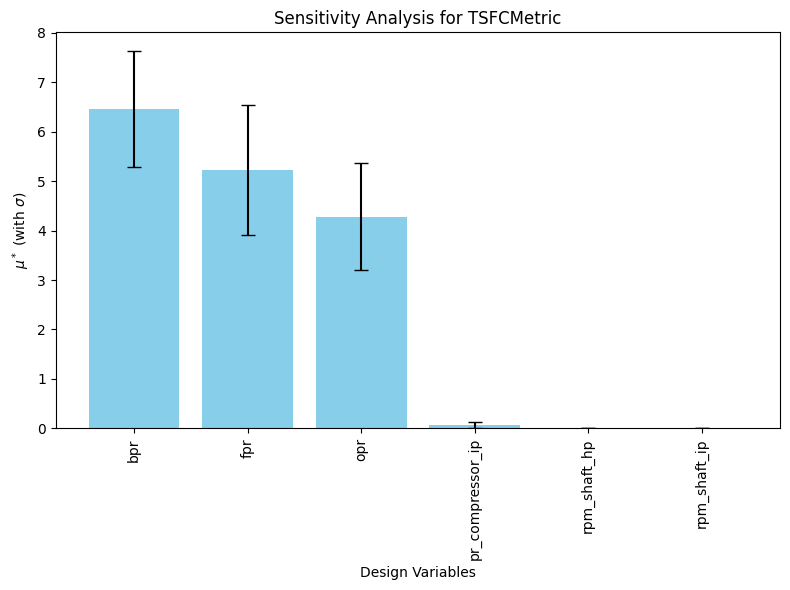

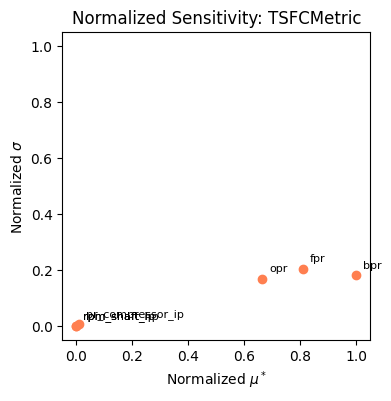

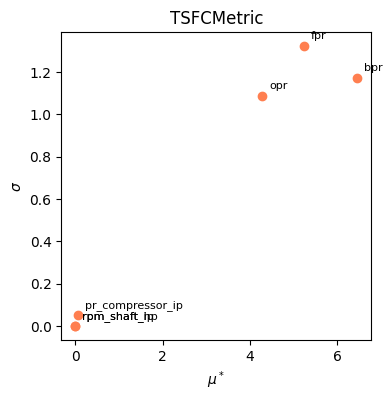


--- Sensitivity for WeightMetric ---


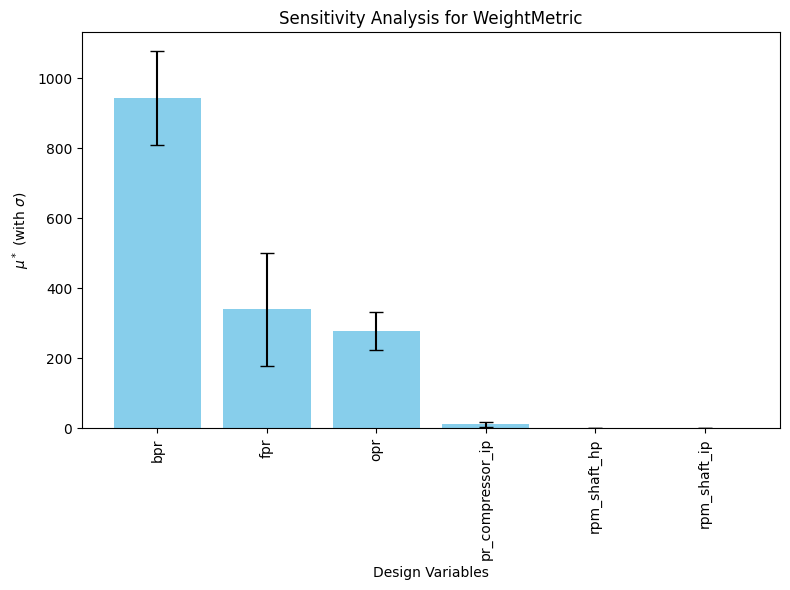

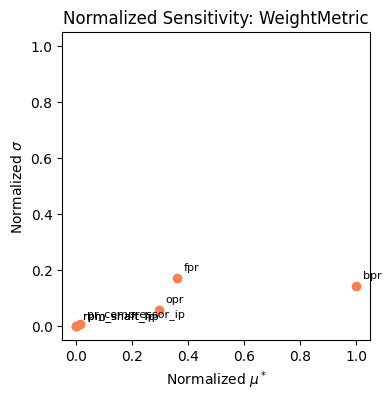

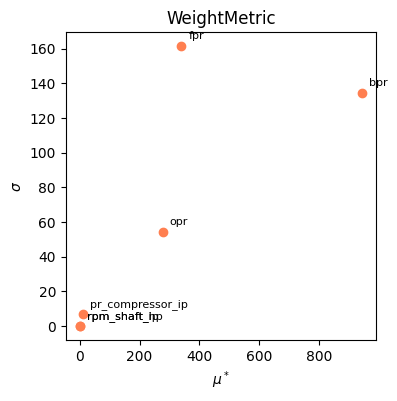


--- Sensitivity for LengthMetric ---


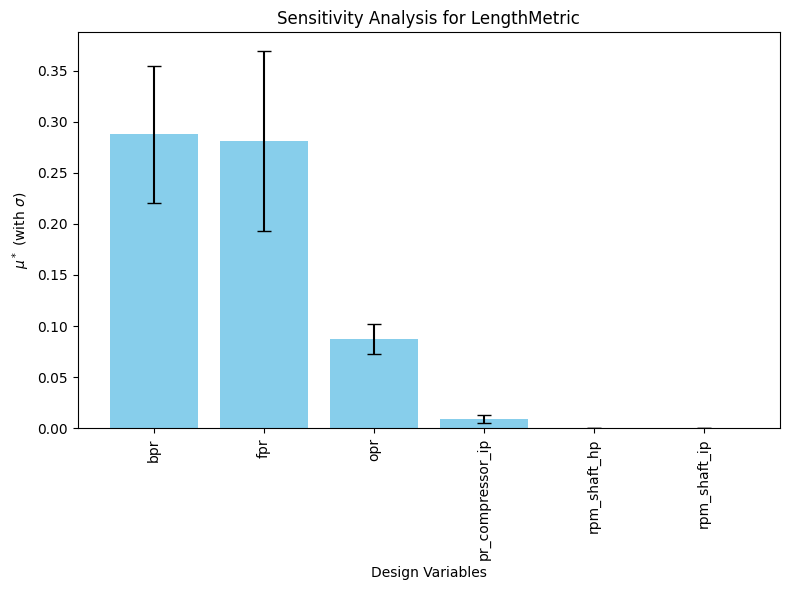

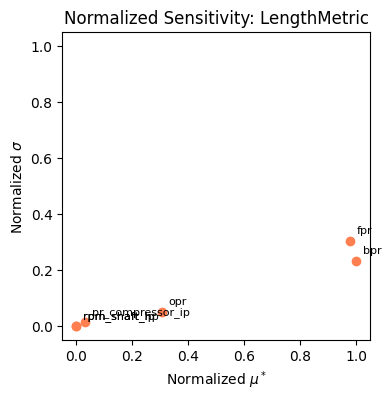

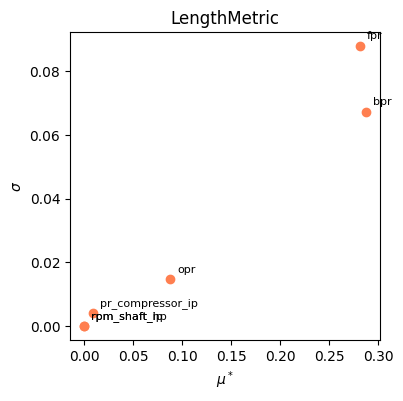


--- Sensitivity for DiameterMetric ---


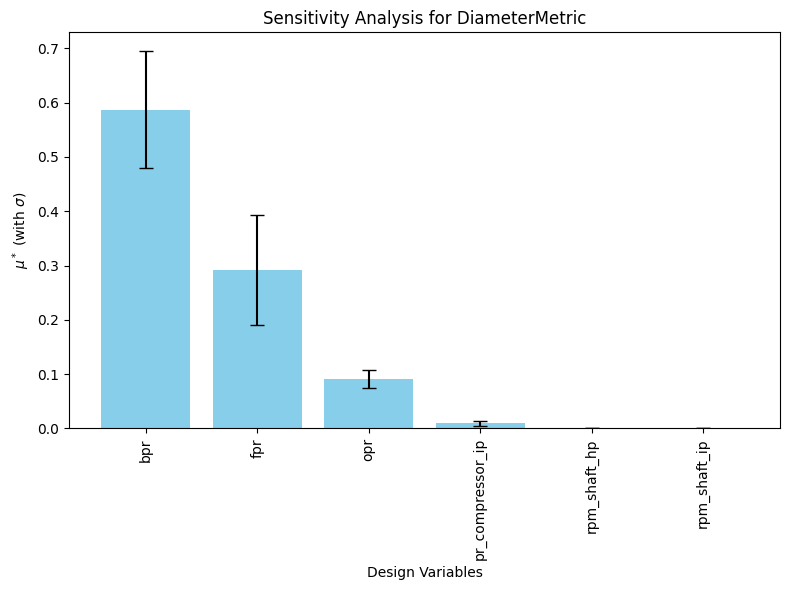

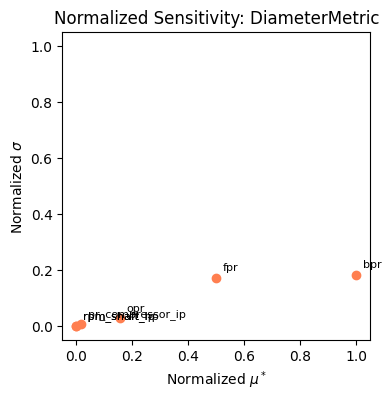

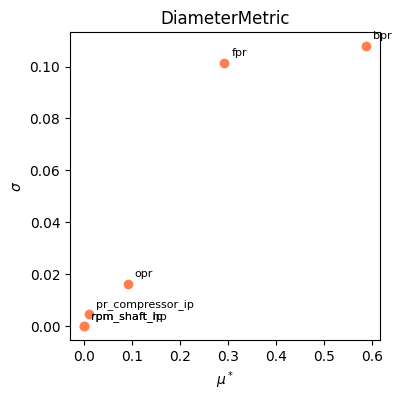


--- Sensitivity for NOxMetric ---


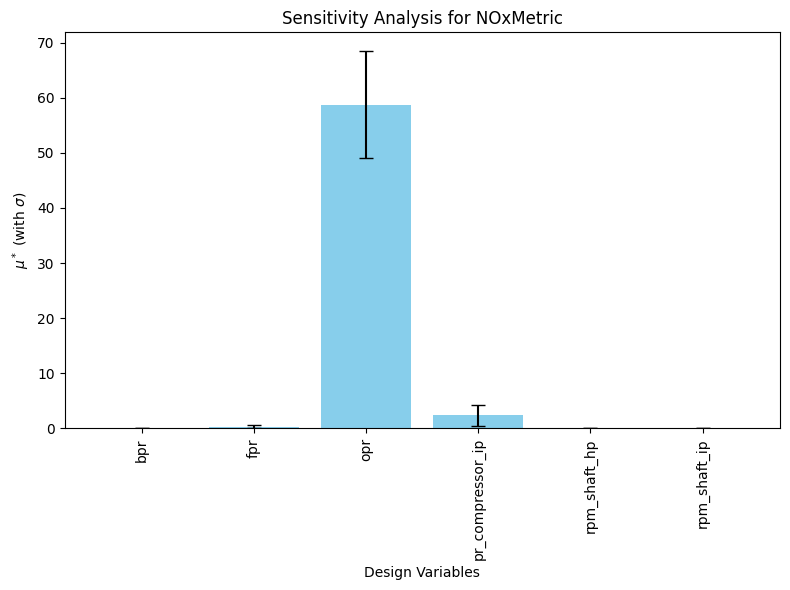

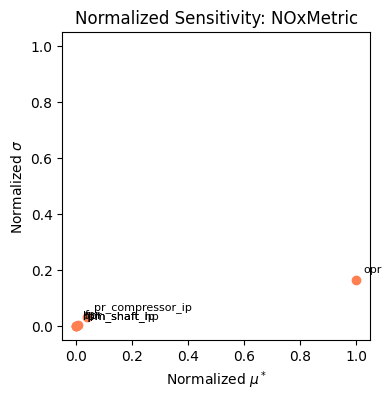

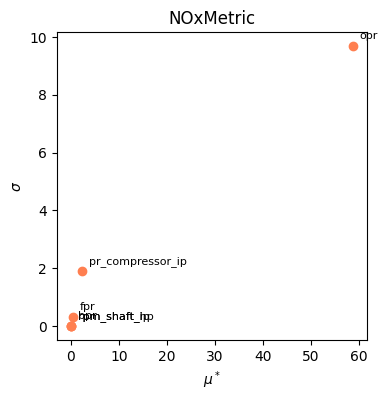


--- Sensitivity for NoiseMetric ---


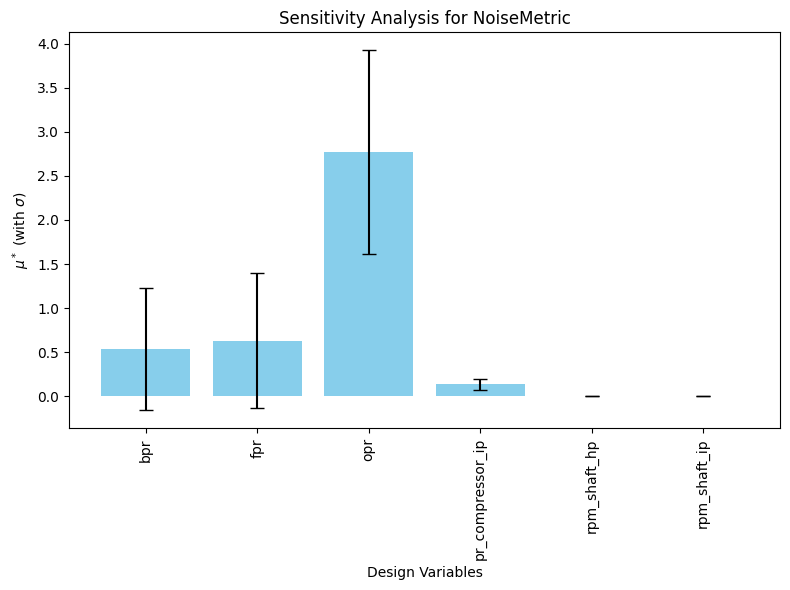

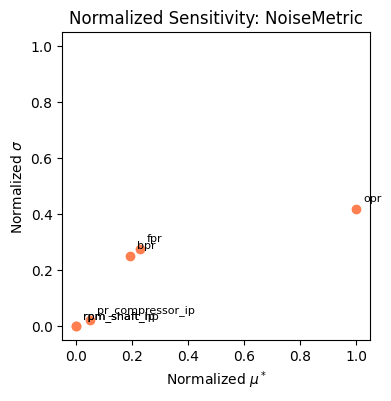

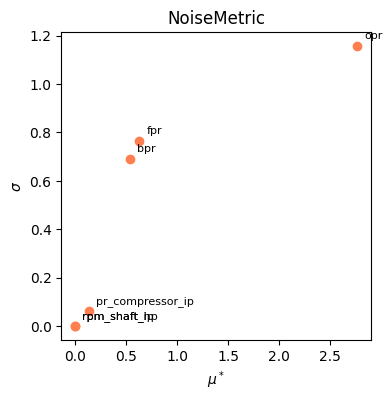


--- Sensitivity for JetMachMetric ---


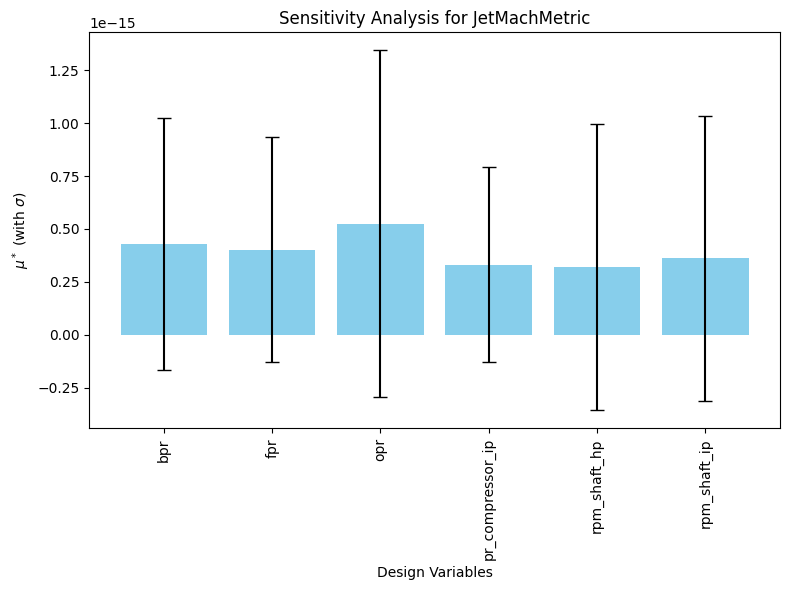

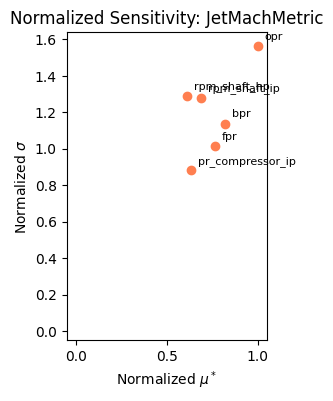

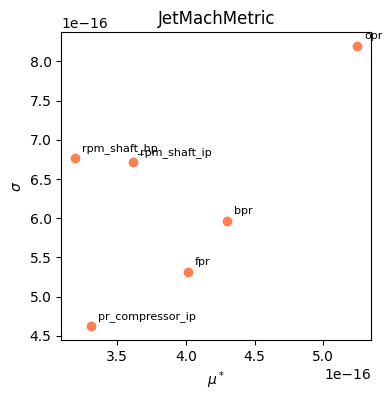

In [28]:
# Define the problem for Morris analysis
active_dv_names = ['bpr',
            'fpr',
            'opr',
            'pr_compressor_ip',
        #   'pr_compressor_lp',
            'rpm_shaft_hp',
            'rpm_shaft_ip',
            # 'rpm_shaft_ip_frac',   # 'rpm_shaft_ip' / 'rpm_shaft_hp'
            
        #   'rpm_shaft_lp',
        #   'gear_ratio',
        #   'far_ab',
        #   'far_itb',
            # 'eb_hb_total',
            # 'eb_hbi_frac_w',
        #   'eb_hbl_frac_w',
            # 'eb_ih_total',
            # 'eb_ihi_frac_w',
        #   'eb_ihl_frac_w',
        #   'eb_li_total',
        #   'eb_lii_frac_w',
        #   'eb_lil_frac_w',
            # 'ab_hpc_total',
            # 'ab_hi_frac_w',
        #   'ab_hl_frac_w',
            # 'ab_ipc_total',
            # 'ab_ii_frac_w',
        #   'ab_il_frac_w',
        #   'ab_lpc_total',
        #   'ab_li_frac_w',
        #   'ab_ll_frac_w',
        #   'ic_location',
        #   'radius',
        #   'length',
        #   'number'
            ]

active_dv_ranges = [[2., 5.], # bpr
        [1.4, 3.0], # fpr
        [20., 80.], # opr
        [0.05, 0.4], # pr_compressor_ip
        # [0.1, 0.9], # pr_compressor_lp
        [10000., 20000.], # rpm_shaft_hp
        [1000., 10000.], # rpm_shaft_ip  
        # [0.1, 0.9], # rpm_shaft_ip_frac                  ## [1000., 10000.], # rpm_shaft_ip
        # [1000., 10000.], # rpm_shaft_lp
        # [1., 5.], # gear_ratio
        # [0., 0.05], # far_ab
        # [0., 0.05], # far_itb
        # [0., 0.05], # eb_hb_total
        # [0., 1.], # eb_hbi_frac_w
        # [0., 1.], # eb_hbl_frac_w
        # [0., 0.05], # eb_ih_total
        # [0., 1.], # eb_ihi_frac_w
        # [0., 1.], # eb_ihl_frac_w
        # [0., 0.1], # eb_li_total
        # [0., 1.], # eb_lii_frac_w
        # [0., 1.], # eb_lil_frac_w
        # [0., 0.05], # ab_hpc_total
        # [0., 1.], # ab_hi_frac_w
        # [0., 1.], # ab_hl_frac_w
        # [0., 0.05], # ab_ipc_total
        # [0., 1.], # ab_ii_frac_w
        # [0., 1.], # ab_il_frac_w
        # [0., 0.1], # ab_lpc_total
        # [0., 1.], # ab_li_frac_w
        # [0., 1.], # ab_ll_frac_w
        # [0, 2],   # ic_location (categorical: 0: none, 1: HPC-ITB, 2: IPC-ITB, 3: LPC-ITB)
        # [0.01, 0.05],   # radius (m)
        # [0.01, 0.05],   # length (m)
        # [1, 251]    # number (integer)
    ]

# Check if length of active_dv_names and active_dv_ranges match
assert len(active_dv_names) == len(active_dv_ranges), "It's not the same"
    
problem = {
    'num_vars': len(active_dv_names),
    'names': active_dv_names,
    'bounds': active_dv_ranges
}

# Normalize X_samples to [0, 1] based on the bounds defined in the problem
X_samples_normalized = np.zeros_like(X_samples)
for i, name in enumerate(problem['names']):
    lower, upper = problem['bounds'][i]
    X_samples_normalized[:, i] = (X_samples[:, i] - lower) / (upper - lower)
    

# Analyze and print the results for EACH objective separately
num_metrics = Y_samples.shape[1]

# We will store the results in a list in case you want to plot them later
all_sensitivity_results = []
all_sensitivity_results_normalized = []

import matplotlib.pyplot as plt

for obj_idx in range(num_metrics):
    print(f"\n========================================")
    print(f"--- Sensitivity for {type(architecting_problem.metrics[obj_idx]).__name__} ---")
    print(f"========================================")
    
    # Slice the matrix to get a 1D array for this specific objective
    Y_single = Y_samples[:, obj_idx]
    
    # Analyze this single objective
    # Note: print_to_console=False so we can format the output ourselves below
    sensitivity_indices = morris_analyze.analyze(problem, X_samples_normalized, Y_single, conf_level=0.95, print_to_console=False)
    
    mu_star = sensitivity_indices['mu_star']
    sigma = sensitivity_indices['sigma']
    
    # Normalize mu_star and sigma by their maximum values for better comparison
    mu_star_normalized = mu_star / np.nanmax(mu_star) if np.nanmax(mu_star) != 0 else mu_star
    sigma_normalized = sigma / np.nanmax(mu_star) if np.nanmax(mu_star) != 0 else sigma
    
    # Save it to our list
    all_sensitivity_results.append(sensitivity_indices)
    all_sensitivity_results_normalized.append((mu_star_normalized, sigma_normalized))
    
    # # Print a clean summary table
    # print(f"{'Variable Name':<20} | {'Mu*':<10} | {'Sigma':<10}")
    # print("-" * 45)
    # for i, name in enumerate(problem['names']):
    #     print(f"{name:<20} | {sensitivity_indices['mu_star'][i]:<10.4f} | {sensitivity_indices['sigma'][i]:<10.4f}")
    
    
    # Plotting the results
    fig, ax= plt.subplots(figsize=(8, 6))
    
    # Bar plot of mu_star with error bars for sigma
    ax.bar(problem['names'], sensitivity_indices['mu_star'], yerr=sensitivity_indices['sigma'], capsize=5, color='skyblue')
    ax.set_xlabel('Design Variables')
    ax.set_ylabel('$\mu^*$ (with $\sigma$)')
    ax.set_title(f'Sensitivity Analysis for {type(architecting_problem.metrics[obj_idx]).__name__}')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
    
    # Plot the scatter normalized mu_star vs sigma
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.scatter(mu_star_normalized, sigma_normalized, color='coral')
    
    for i, name in enumerate(problem['names']):
        ax.annotate(name, (mu_star_normalized[i], sigma_normalized[i]), textcoords="offset points", xytext=(5,5), ha='left', fontsize=8)
    
    ax.set_xlabel('Normalized $\mu^*$')
    ax.set_ylabel('Normalized $\sigma$')
    ax.set_title(f'Normalized Sensitivity: {type(architecting_problem.metrics[obj_idx]).__name__}')
    
    ax.set_xlim(-0.05, 1.05)  # Set x-axis limits to [0, 1.1] for better visualization
    
    sigma_normalized_max = np.nanmax(sigma_normalized)
    if sigma_normalized_max > 1:
        ax.set_ylim(-0.05, sigma_normalized_max * 1.05)  # Set y-axis limits based on max sigma for better visualization
    else:
        ax.set_ylim(-0.05, 1.05)  # Set y-axis limits to [0, 1.1] for better visualization
    
    # Set aspect ratio to 1 for better visualization
    ax.set_aspect('equal')
    
    plt.show()
    
    # Plot the scatter mu_star vs sigma
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.scatter(mu_star, sigma, color='coral')
    
    for i, name in enumerate(problem['names']):
        ax.annotate(name, (mu_star[i], sigma[i]), textcoords="offset points", xytext=(5,5), ha='left', fontsize=8)
    
    ax.set_xlabel('$\mu^*$')
    ax.set_ylabel('$\sigma$')
    ax.set_title(f'{type(architecting_problem.metrics[obj_idx]).__name__}')
    plt.show()

efficiencies: keep equal, at the best that i have

morris: global, assume hypercube. our case: not hupercube, some combinations are impossible. solution: try local sensitivity analysys. for example: 1st: DV, 2nd: efficiencies, 3rd: cooling

about the RP itsef:
1. validation
2. optimization (+ sensitivity analysis)
3. explore categorical var.

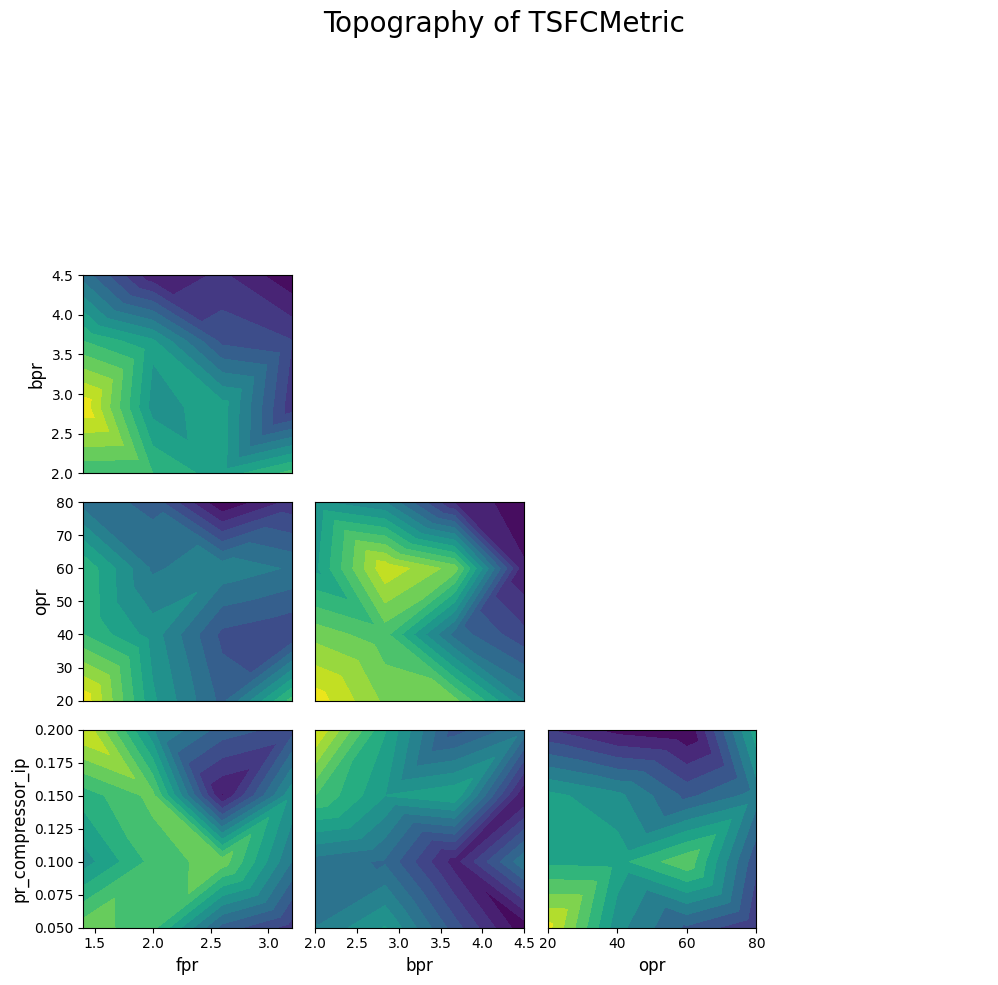

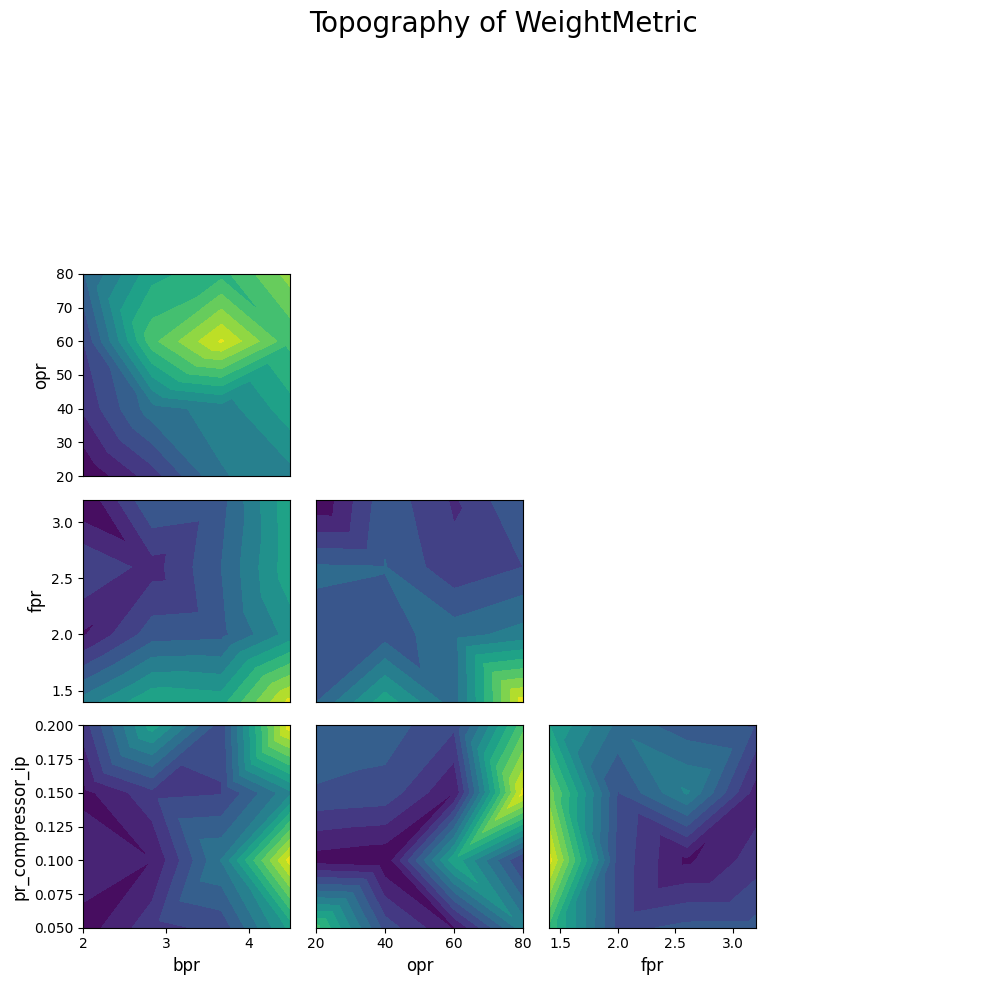

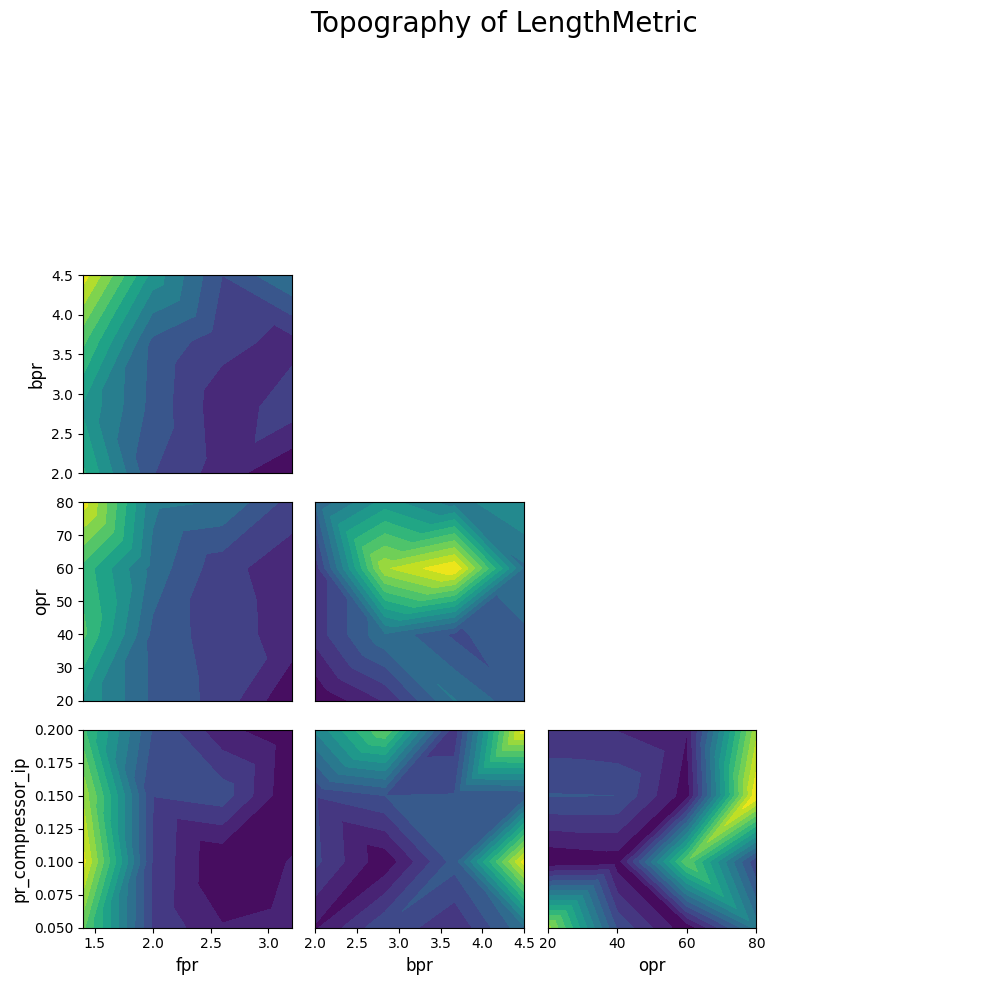

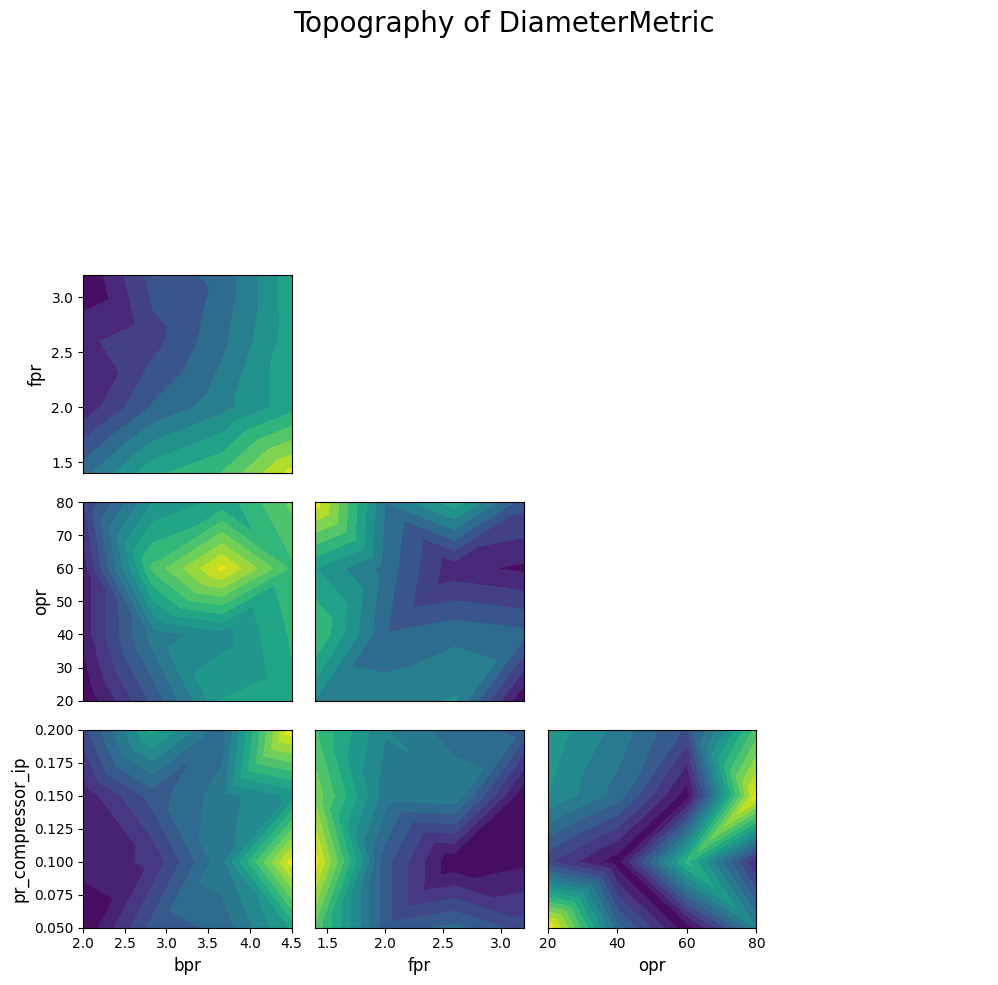

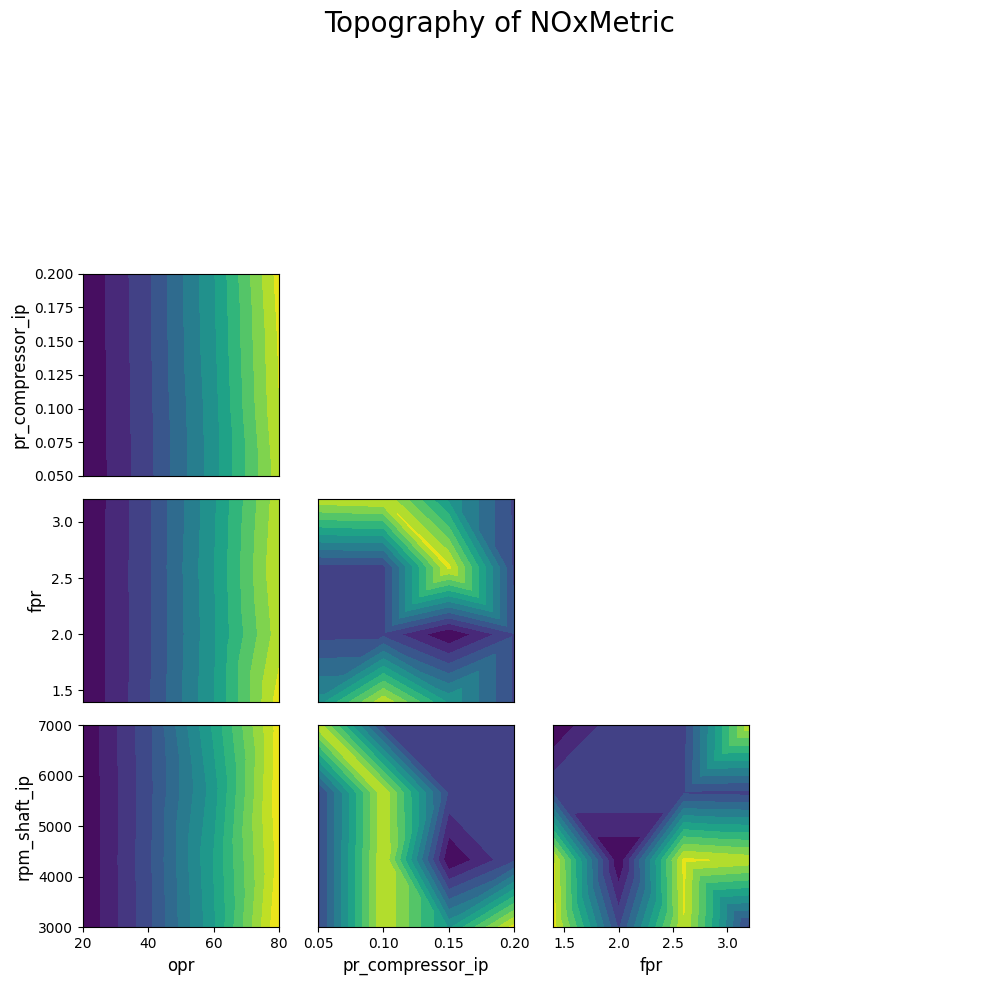

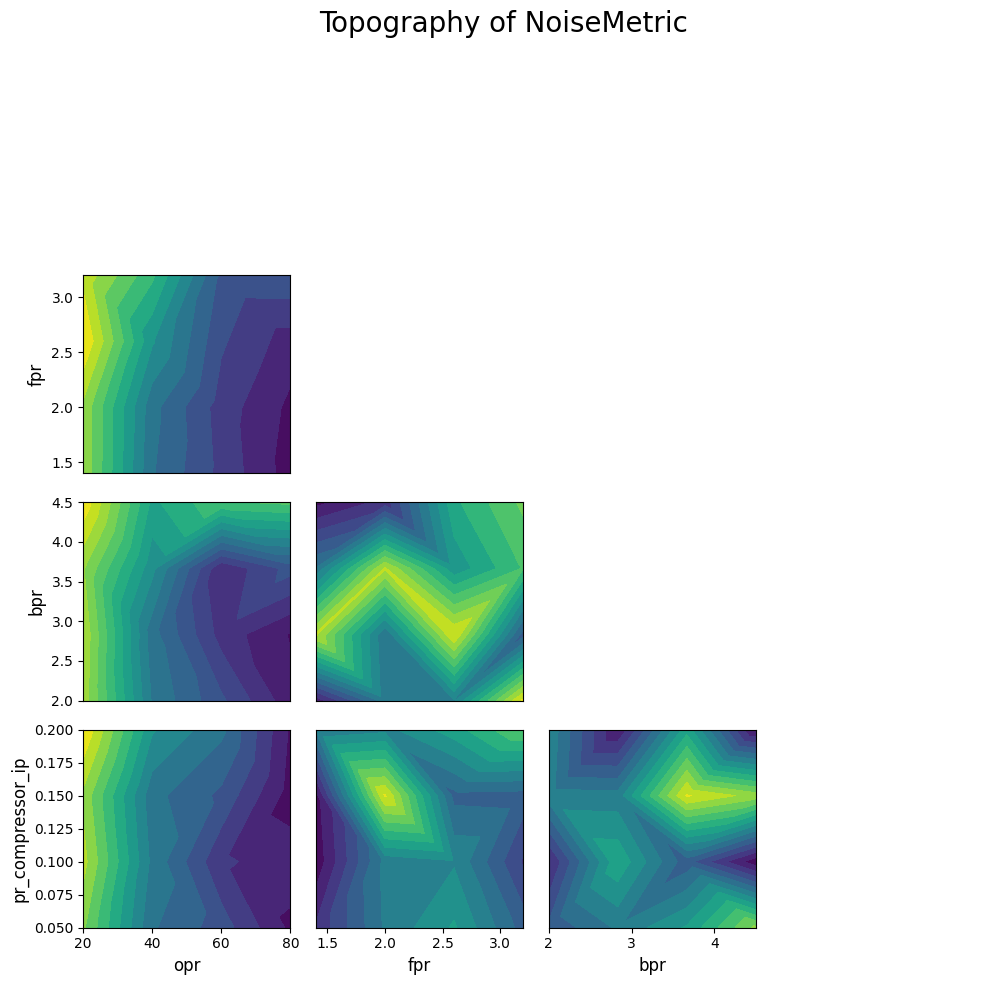

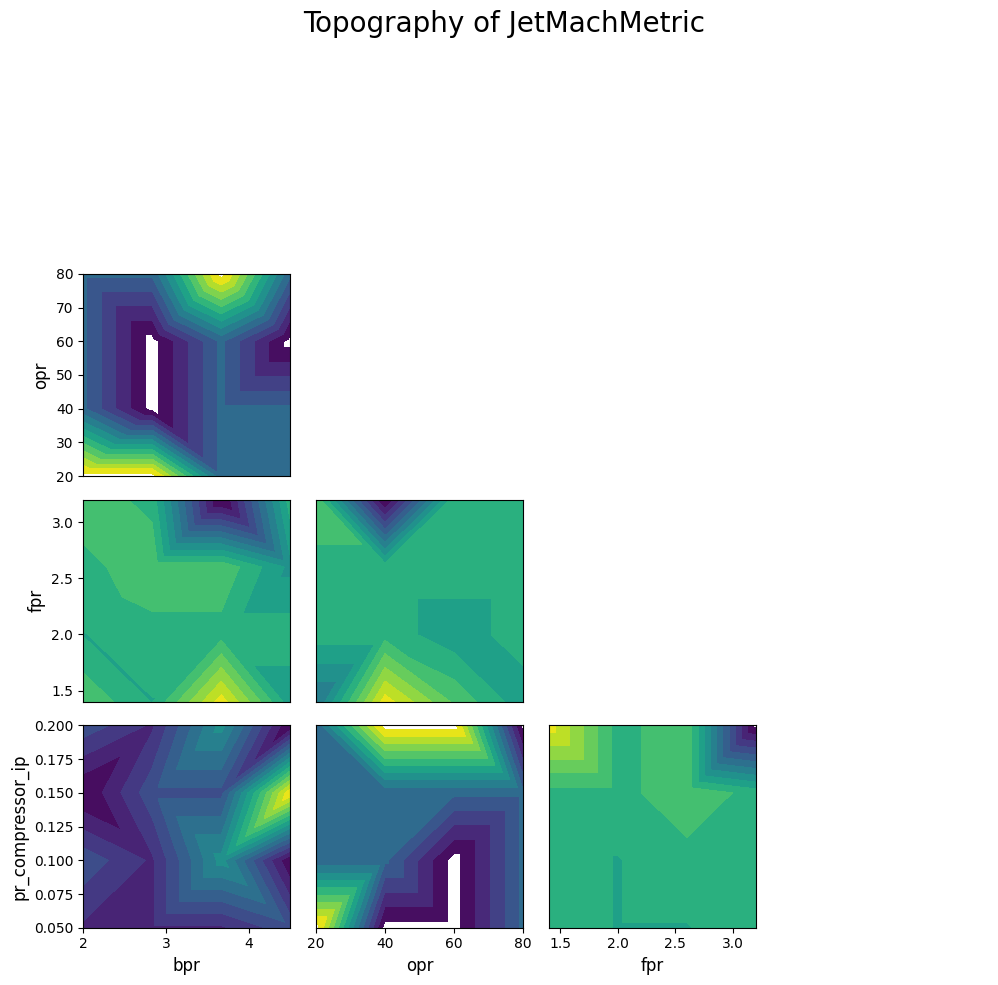

In [12]:
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation

def plot_hills_matrix(X, Y, x_labels, metric_name, top_n=6, mu_star=None, sigma=None):
    """
    X: (N, 14) array
    Y: (N,) array (a single column from Y_samples)
    x_labels: list of 14 strings
    top_n: Number of variables to include in the matrix
    """
    # 1. Identify the top variables for this metric (based on your sensitivity results)
    # For now, let's just pick the first few, or you can pass the top indices
    indices = range(top_n) 
    
    fig, axes = plt.subplots(top_n, top_n, figsize=(10, 10))
    fig.suptitle(f'Topography of {metric_name}', fontsize=20)
    
    # Sort the variables by mu_star for better visualization (optional)
    if mu_star is not None:
        sorted_indices = np.argsort(mu_star)[::-1][:top_n]
        X = X[:, sorted_indices]
        x_labels = [x_labels[i] for i in sorted_indices]
        
    Y_max = np.nanmax(Y)
    Y_min = np.nanmin(Y)
    
    # Normalize Y for color mapping
    Y_normalized = (Y - Y_min) / (Y_max - Y_min) if Y_max > Y_min else Y

    for i in range(top_n):
        for j in range(top_n):
            # Only solve lower triangle and diagonal to avoid redundant plots
            if j >= i:
                axes[i, j].axis('off')
                continue
            
            ax = axes[i, j]
            
            if i == j:
                # Diagonal: Histogram of the distribution
                ax.hist(X[:, i], bins=20, color='skyblue', edgecolor='black')
                # ax.set_title(x_labels[i])
            else:
                # Off-diagonal: The "Hills"
                # We use Triangulation to handle scattered X, Y points
                try:
                    tri = Triangulation(X[:, j], X[:, i])
                    contour = ax.tricontourf(tri, Y_normalized, cmap='viridis', levels=15)
                    # Use 'terrain' or 'viridis' for a "hill" look
                except:
                    pass # Handles cases where points are collinear
            
            if i < top_n - 1: ax.set_xticks([])
            if j > 0: ax.set_yticks([])
            
            if i == top_n - 1:
                ax.set_xlabel(x_labels[j], fontsize=12)
            if j == 0:
                ax.set_ylabel(x_labels[i], fontsize=12)
            
            # # Add mu_star and sigma as text annotations in the top-left corner of each subplot
            # if mu_star is not None and sigma is not None:
            #     mu_text = f'$\mu^*$={mu_star[j]:.2f}'
            #     sigma_text = f'$\sigma$={sigma[j]:.2f}'
            #     ax.text(0.05, 0.95, mu_text + '\n' + sigma_text, transform=ax.transAxes, fontsize=8, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            
    plt.tight_layout()
    plt.show()

# Example usage for your first metric (TSFC)
for i in range(num_metrics):
    metric_name = type(architecting_problem.metrics[i]).__name__
    plot_hills_matrix(X_samples, Y_samples[:, i], active_dv_names, metric_name, top_n=4, mu_star=all_sensitivity_results[i]['mu_star'], sigma=all_sensitivity_results[i]['sigma'])

In [13]:
# Calculate and print the correlation matrix for the active design variables
import pandas as pd
df = pd.DataFrame(X_samples, columns=problem['names'])
print("Correlation matrix for active design variables:")
display(df.corr())

Correlation matrix for active design variables:


,bpr,fpr,opr,pr_compressor_ip,rpm_shaft_hp,rpm_shaft_ip
bpr,1.000000,0.010840,-0.078736,0.066362,-0.012291,0.021853
fpr,0.010840,1.000000,0.010968,0.067748,0.014438,0.083518
opr,-0.078736,0.010968,1.000000,0.101753,-0.095896,0.108526
pr_compressor_ip,0.066362,0.067748,0.101753,1.000000,0.147151,0.080076
rpm_shaft_hp,-0.012291,0.014438,-0.095896,0.147151,1.000000,-0.016684
rpm_shaft_ip,0.021853,0.083518,0.108526,0.080076,-0.016684,1.000000
